# Customer Segmentation

Goal: group members into segments based on **behavior + value**, not just
raw CLV - the problem statement specifically asks us to interrogate
whether CLV alone tells the full story.

We use `KMeans` clustering on a handful of features that capture how much
someone flies, how engaged/satisfied they seem, and how valuable they are.
Picks up from `customer_churn_scored.csv` (built in `Churn_Prediction_Model.ipynb`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('customer_churn_scored.csv')
print(df.shape)
df.head(3)

(13699, 34)


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Net Reward Points,Redeem Ratio,Months Since Last Flight,Flights in last 3 months,Flights in last 6 months,Engagement Score,Cancelled In Label Window,Churn,churn_risk_score,churn_risk_tier
0,480934,canada,ontario,toronto,m2z 4k1,female,bachelor,83236.0,married,star,...,30770.0,0.01,1,6,6,0.162575,False,0,0.229263,Low Risk
1,549612,canada,alberta,edmonton,t3g 6y6,male,college,73455.0,divorced,star,...,55159.0,0.02,0,11,14,0.225587,False,0,0.278039,Low Risk
2,608370,canada,ontario,toronto,p1w 1k4,male,college,73455.0,single,star,...,41290.0,0.02,0,3,6,0.267894,False,0,0.201028,Low Risk


## 1. Choosing the segmentation features

We deliberately mix three kinds of signal:
- **Behavior**: `Total Flights in Lifetime`, `Total Distance`
- **Engagement/satisfaction**: `Redeem Ratio`, `Months Since Last Flight`
- **Value**: `CLV`

A member can have high CLV but be about to churn
or have modest CLV but be extremely
loyal and consistent. Clustering on value alone would hide that.

In [3]:
segment_features = [
    'Total Flights in Lifetime',
    'Total Distance',
    'Redeem Ratio',
    'Months Since Last Flight',
    'CLV',
]

X = df[segment_features].copy()
X.describe()

,Total Flights in Lifetime,Total Distance,Redeem Ratio,Months Since Last Flight,CLV
count,13699.000000,13699.000000,13699.000000,13699.000000,13699.000000
mean,24.297467,36383.576976,0.017146,46.359953,7967.206179
std,10.667169,16892.099973,0.022273,208.648142,6815.466918
min,0.000000,0.000000,0.000000,0.000000,1898.010000
25%,19.000000,26558.500000,0.000000,0.000000,3979.490000
50%,26.000000,37655.000000,0.013000,0.000000,5780.180000
75%,32.000000,47619.000000,0.026000,1.000000,8937.120000
max,74.000000,119399.000000,0.744000,999.000000,83325.380000


## 2. Standardizing the features

`KMeans` is a distance based algorithm so we need to standardize the numerical values first.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Choosing K with the elbow method


K=2: inertia=47948
K=3: inertia=35263
K=4: inertia=27886
K=5: inertia=23165
K=6: inertia=20032
K=7: inertia=17234
K=8: inertia=15736


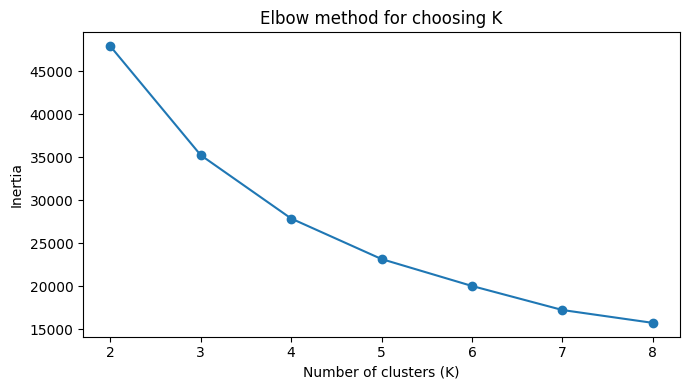

In [5]:
inertias = []
k_values = range(2, 9)

for k in k_values:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inertias.append(kmeans_test.inertia_)
    print(f'K={k}: inertia={kmeans_test.inertia_:.0f}')

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow method for choosing K')
plt.tight_layout()
plt.show()

Based on the elbow, and wanting segments a marketing team can actually
act on (not too many, not too few), we go with **K=5**.

In [6]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

df['segment'].value_counts()

,count
segment,
1,6533
2,3853
0,1676
3,1011
4,626


## 4. What does each segment actually look like?

In [7]:
segment_profile = df.groupby('segment')[segment_features + ['churn_risk_score']].mean().round(2)
segment_profile['num_customers'] = df.groupby('segment').size()
segment_profile = segment_profile.sort_values('CLV', ascending=False)

segment_profile

,Total Flights in Lifetime,Total Distance,Redeem Ratio,Months Since Last Flight,CLV,churn_risk_score,num_customers
segment,,,,,,,
3,26.42,39420.68,0.02,1.62,26338.54,0.23,1011
4,0.00,0.00,0.00,999.00,8163.09,0.76,626
0,19.06,26574.32,0.05,0.92,6724.86,0.27,1676
2,16.85,24603.46,0.01,0.89,6385.28,0.31,3853
1,32.03,48864.01,0.01,0.47,6357.12,0.21,6533


## 5. Naming the segments

We name the segments based on their behaviour.

In [8]:
profile = segment_profile.reset_index()

profile['flight_rank'] = profile['Total Flights in Lifetime'].rank(ascending=False)

segment_id_to_name = {}
for _, row in profile.iterrows():
    if row['Total Flights in Lifetime'] < 1:
        name = 'Dormant / Never Flew'
    elif row['flight_rank'] == 1:
        name = 'Champions (high flights, low churn)'
    elif row['CLV'] > 10000:
        name = 'High Value Flyers'
    elif row['churn_risk_score'] > 0.3:
        name = 'Occasional / Higher Churn Risk'
    else:
        name = 'Engaged / Mid-Tier Loyalty'
    segment_id_to_name[row['segment']] = name

df['segment_name'] = df['segment'].map(segment_id_to_name)

df['segment_name'].value_counts()

,count
segment_name,
"Champions (high flights, low churn)",6533
Occasional / Higher Churn Risk,3853
Engaged / Mid-Tier Loyalty,1676
High Value Flyers,1011
Dormant / Never Flew,626


In [9]:
print('Average churn risk by segment:')
df.groupby('segment_name')['churn_risk_score'].mean().round(3).sort_values(ascending=False)

Average churn risk by segment:


,churn_risk_score
segment_name,
Dormant / Never Flew,0.759
Occasional / Higher Churn Risk,0.315
Engaged / Mid-Tier Loyalty,0.268
High Value Flyers,0.231
"Champions (high flights, low churn)",0.213


## 6. A quick visual: segments by value and engagement

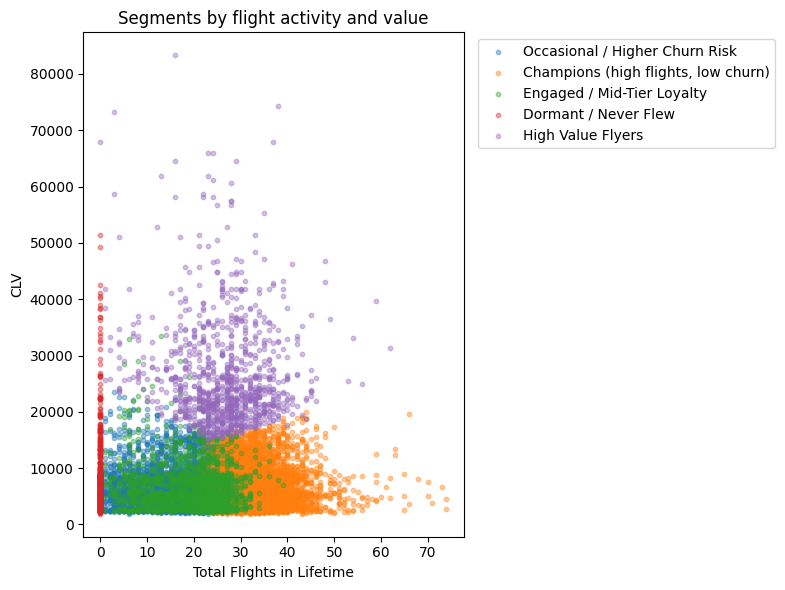

In [10]:
plt.figure(figsize=(8, 6))
for name in df['segment_name'].unique():
    subset = df[df['segment_name'] == name]
    plt.scatter(subset['Total Flights in Lifetime'], subset['CLV'], label=name, alpha=0.4, s=10)

plt.xlabel('Total Flights in Lifetime')
plt.ylabel('CLV')
plt.title('Segments by flight activity and value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Save

This feeds into the retention playbook notebook next - segments + churn
risk together are what let us assign a specific action to each group.

In [11]:
df.to_csv('customer_segments.csv', index=False)
files.download('customer_segments.csv')
print('Saved customer_segments.csv with', df.shape[0], 'rows')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved customer_segments.csv with 13699 rows
